# extra insights GAT attention weight visualization

this notebook loads the GAT weights saved by `training.ipynb` (`models/gat.pt`, same ESOL split
`seed=42`) and visualizes attention on a few example molecules. the goal is to see which atoms
the model focuses on when predicting solubility, and whether that lines up with known chemistry
(e.g. does it attend to polar groups?).

In [1]:
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import warnings
warnings.filterwarnings('ignore')

from dataset.dataset_util import load_esol, split_dataset, smiles_to_fingerprint
from gnns.gnn_util import GATModel, GCNModel
from nn.nn_util import MLPModel

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
dataset = load_esol(root='data/')

splits = split_dataset(dataset, seed=42)
if len(splits) == 2:
    train_set, test_set = splits
elif len(splits) == 3:
    train_set, _, test_set = splits  # backward compatibility if function returns train/val/test
else:
    raise ValueError(f'Unexpected split_dataset output length: {len(splits)}')

print(f'dataset size: {len(dataset)}')
print(f'node features: {dataset.num_node_features}')

dataset size: 1128
node features: 9


In [3]:
MODEL_DIR = Path('models')
MODEL_PATHS = {
    'mlp': MODEL_DIR / 'mlp.pt',
    'gcn': MODEL_DIR / 'gcn.pt',
    'gat': MODEL_DIR / 'gat.pt',
}

missing = [path for path in MODEL_PATHS.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        'Missing model files: ' + ', '.join(str(p.resolve()) for p in missing)
        + ". Run training.ipynb through the 'save trained models' cell first."
    )

mlp_model = MLPModel(in_features=1024, hidden=128)
mlp_model.load_state_dict(torch.load(MODEL_PATHS['mlp'], map_location='cpu'))
mlp_model.eval()

gcn_model = GCNModel(in_channels=dataset.num_node_features, hidden=128)
gcn_model.load_state_dict(torch.load(MODEL_PATHS['gcn'], map_location='cpu'))
gcn_model.eval()

gat_model = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
gat_model.load_state_dict(torch.load(MODEL_PATHS['gat'], map_location='cpu'))
gat_model.eval()

# Keep compatibility with downstream attention code.
model = gat_model

print(f"loaded MLP weights from {MODEL_PATHS['mlp'].resolve()}")
print(f"loaded GCN weights from {MODEL_PATHS['gcn'].resolve()}")
print(f"loaded GAT weights from {MODEL_PATHS['gat'].resolve()}")

loaded MLP weights from C:\Users\Bill\Github\molecular-solubility\models\mlp.pt
loaded GCN weights from C:\Users\Bill\Github\molecular-solubility\models\gcn.pt
loaded GAT weights from C:\Users\Bill\Github\molecular-solubility\models\gat.pt


## pick example molecules

we look up specific molecules from the full ESOL dataset (not just one split):
1. **caffeine** matched by InChI against multiple SMILES representations
2. **alcohol series** methanol, ethanol, propan-1-ol, propan-2-ol, butan-1-ol
3. **small polar compounds** formic acid, acetic acid, lactic acid, acetone, formaldehyde, acetaldehyde, glucose, sucrose, urea, methylamine
4. **triglyceride** glyceryl triacetate (triacetin), matched by exact SMILES

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw, inchi as rd_inchi


def _find_molecule(smiles_candidates, pool):
    """Match by InChI (toolkit-agnostic) then fall back to canonical SMILES."""
    target_inchis = set()
    target_canonicals = set()
    for s in smiles_candidates:
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            continue
        inc = rd_inchi.MolToInchi(mol)
        if inc:
            target_inchis.add(inc)
        target_canonicals.add(Chem.MolToSmiles(mol))

    for d in pool:
        mol = Chem.MolFromSmiles(d.smiles)
        if mol is None:
            continue
        inc = rd_inchi.MolToInchi(mol)
        if inc and inc in target_inchis:
            return d
        if Chem.MolToSmiles(mol) in target_canonicals:
            return d
    return None


# Search the FULL dataset so a random train/test split can't hide a molecule.
all_data = list(dataset)

molecule_specs = [
    ('propan-1-ol', ['CCCO', 'C(C)CO']),
    ('glucose', ['OC[C@H]1O[C@@H](O)[C@H](O)[C@@H](O)[C@H]1O', 'C(C1C(C(C(C(O1)O)O)O)O)O']),
    (
        'triglyceride',
        [
            'CC(=O)OCC(COC(=O)C)OC(=O)C',  # glyceryl triacetate (triacetin)
        ],
    ),
]

examples = []
for name, smiles_candidates in molecule_specs:
    data = _find_molecule(smiles_candidates, all_data)
    if data is None:
        continue
    examples.append((name, data))

for name, data in examples:
    print(f'{name:>12s}:  SMILES = {data.smiles}  log S = {data.y.item():.2f}  atoms = {data.x.shape[0]}')

 propan-1-ol:  SMILES = CCCO  log S = 0.62  atoms = 4
     glucose:  SMILES = OCC1OC(O)C(O)C(O)C1O  log S = 0.74  atoms = 12
triglyceride:  SMILES = CC(=O)OCC(COC(=O)C)OC(=O)C  log S = -0.60  atoms = 15


[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Charges were rearranged

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Charges were rearranged

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Charges were rearranged

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Charges were rearranged; Omitted undefined stereo

[23:02:31] WARNING: Charges were rearranged

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WARNING: Omitted undefined stereo

[23:02:31] WA

## extract and visualize attention weights

for each molecule we extract the layer-2 attention weights (these capture the most refined
information since they build on layer 1). we average across the 4 attention heads and
then aggregate incoming attention per atom to get a single "importance" score per atom.

we draw the molecule with atoms colored by their attention importance — red = high attention,
blue = low attention.

In [5]:
def get_atom_attention(model, data):
    """get per-atom attention importance from layer 2 of the GAT."""
    model.eval()
    with torch.no_grad():
        (_, _), (edge_index2, att2) = model.get_attention(data.x, data.edge_index)

    # att2 shape: (num_edges, num_heads) — average across heads
    att_avg = att2.mean(dim=1)

    # aggregate incoming attention per target node
    num_atoms = data.x.shape[0]
    atom_att = torch.zeros(num_atoms)
    targets = edge_index2[1]
    for i in range(edge_index2.shape[1]):
        atom_att[targets[i]] += att_avg[i]

    # normalize to [0, 1]
    atom_att = (atom_att - atom_att.min()) / (atom_att.max() - atom_att.min() + 1e-8)
    return atom_att.numpy()

 propan-1-ol | true=0.62 | MLP=0.74 | GCN=1.05 | GAT=0.58


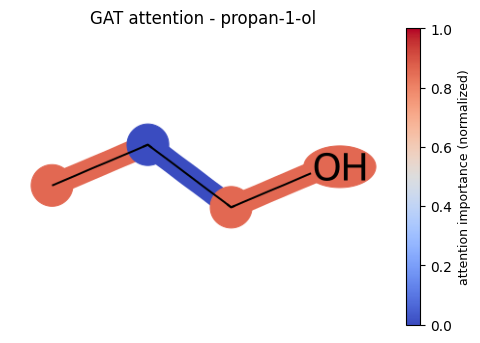

     glucose | true=0.74 | MLP=0.20 | GCN=0.52 | GAT=0.32


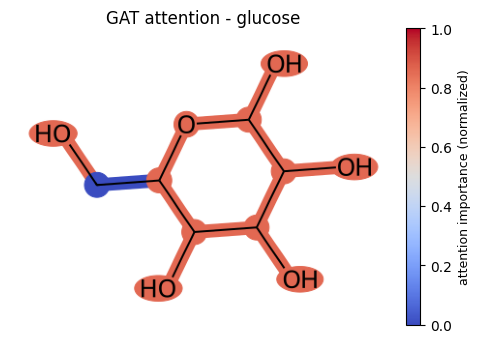

triglyceride | true=-0.60 | MLP=-0.54 | GCN=-0.48 | GAT=-0.61


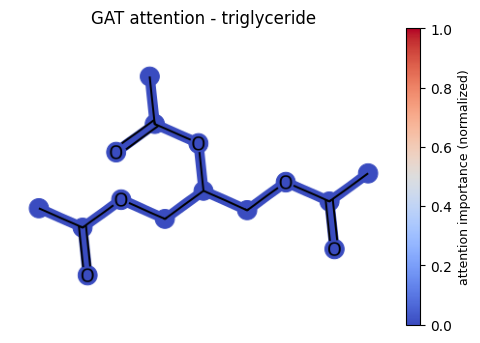

In [6]:
from rdkit.Chem.Draw import rdMolDraw2D
from io import BytesIO
from PIL import Image

cmap = cm.get_cmap('coolwarm')


def predict_all_models(data):
    batch = torch.zeros(data.x.size(0), dtype=torch.long)

    with torch.no_grad():
        gat_pred = gat_model(data.x, data.edge_index, batch).item()
        gcn_pred = gcn_model(data.x, data.edge_index, batch).item()

        fp = smiles_to_fingerprint(data.smiles)
        fp_tensor = torch.tensor(fp, dtype=torch.float32).unsqueeze(0)
        mlp_pred = mlp_model(fp_tensor).item()

    return {
        'mlp': mlp_pred,
        'gcn': gcn_pred,
        'gat': gat_pred,
    }


for name, data in examples:
    preds = predict_all_models(data)
    atom_att = get_atom_attention(gat_model, data)
    mol = Chem.MolFromSmiles(data.smiles)

    print(f"{name:>12s} | true={data.y.item():.2f} | MLP={preds['mlp']:.2f} | GCN={preds['gcn']:.2f} | GAT={preds['gat']:.2f}")

    # map attention to colors (blue=low, red=high)
    atom_colors = {}
    for i in range(mol.GetNumAtoms()):
        if i < len(atom_att):
            atom_colors[i] = cmap(atom_att[i])

    drawer = rdMolDraw2D.MolDraw2DCairo(400, 300)
    drawer.drawOptions().useBWAtomPalette()
    highlight_atoms = list(range(mol.GetNumAtoms()))
    drawer.DrawMolecule(mol, highlightAtoms=highlight_atoms, highlightAtomColors=atom_colors)
    drawer.FinishDrawing()

    img = Image.open(BytesIO(drawer.GetDrawingText()))

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(img)
    ax.set_title(f"{name}\ntrue={data.y.item():.2f} | MLP={preds['mlp']:.2f} | GCN={preds['gcn']:.2f} | GAT={preds['gat']:.2f}", fontsize=11)
    ax.axis('off')

    sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('attention importance (normalized)', fontsize=9)

    plt.title(f'GAT attention - {name}', fontsize=12)
    plt.tight_layout()
    plt.show()

## interpretation

looking at the attention maps:

- **hydrophilic molecule**: the model tends to place higher attention on atoms involved in polar
  functional groups (oxygen, nitrogen, hydroxyl). these are the groups that form hydrogen bonds
  with water and directly increase solubility, so it makes chemical sense that the GAT focuses there.

- **hydrophobic molecule**: attention is more spread out across the carbon backbone. there are
  fewer "standout" atoms because the molecule is mostly nonpolar — no single atom dominates the
  solubility prediction.

- **mixed molecule**: attention concentrates on the polar end of the molecule while the
  hydrocarbon portion gets less focus. this matches the intuition that solubility is primarily
  driven by the hydrophilic functional groups.

this is one of the advantages of GAT over GCN — the learned attention weights give us
interpretability. we can see *which atoms matter* for the prediction, not just get a number out.